In [2]:
import pandas as pd
df = pd.read_csv("/content/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.shape


(150, 6)

In [4]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


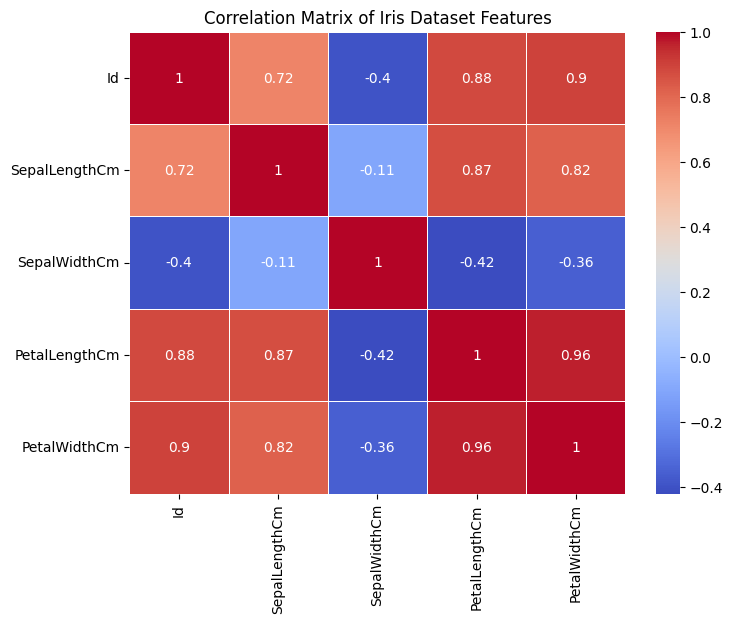

In [17]:
correlation_matrix = df.corr(numeric_only=True)  # `numeric_only=True` to avoid warning about non-numeric columns

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=.5)  # Added linewidths for clarity
plt.title("Correlation Matrix of Iris Dataset Features")
plt.show()

In [7]:
X = df.drop(columns=['Species', 'Id'])  # Drop 'Species' (target) and 'Id' (irrelevant column)
y = df['Species']  # Target variable

# Step 3: Encode the target labels (if necessary)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



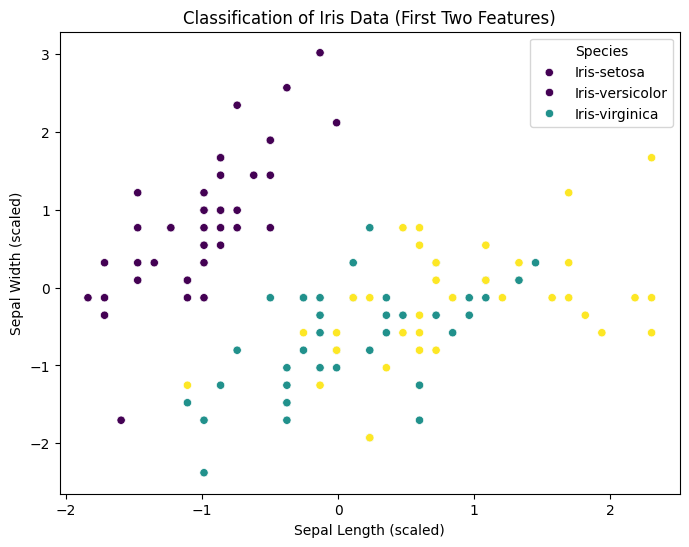

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
target_names = df['Species'].unique()
# Visualize the data using the first two features
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, palette='viridis')
plt.title('Classification of Iris Data (First Two Features)')
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.legend(title='Species', labels=target_names)
plt.show()

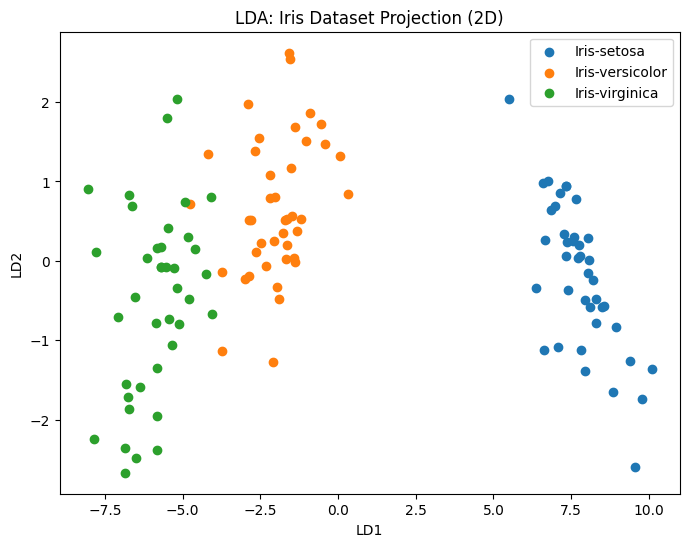

In [12]:
# Step 7: Visualize the transformed data (optional)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # Import LDA

# Calculate X_train_lda before using it
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train, y_train)

plt.figure(figsize=(8, 6))
for i, species in enumerate(le.classes_):
    plt.scatter(X_train_lda[y_train == i, 0], X_train_lda[y_train == i, 1], label=species)
plt.title('LDA: Iris Dataset Projection (2D)')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.show()

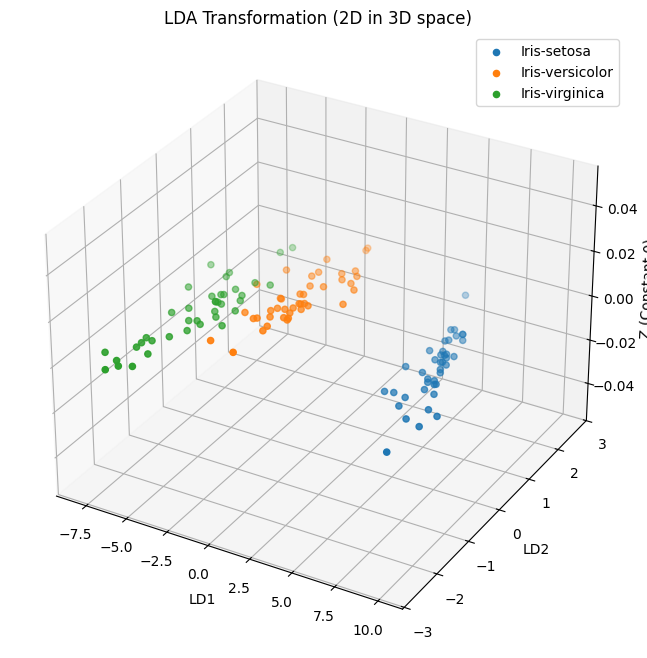

In [13]:
from mpl_toolkits.mplot3d import Axes3D  # Import for 3D plotting

# Apply LDA with 2 components (max allowed since we have 3 classes)
lda = LinearDiscriminantAnalysis(n_components=2)  # Corrected to 2 components
X_train_lda = lda.fit_transform(X_train, y_train)
target_names = df['Species'].unique()  # Use correct column name

# 3D Visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')  # Create a 3D subplot

# Scatter plot - CORRECTED plotting by looping through species
for i, species in enumerate(target_names):
    ax.scatter(X_train_lda[y_train == i, 0],  # LD1 for this species
               X_train_lda[y_train == i, 1],  # LD2 for this species
               zs=0,  # Z-coordinate set to 0 for all points
               zdir='z',  # Plot on the Z=0 plane
               label=species)  # Label for this species

ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_zlabel('Z (Constant 0)')  # Indicate that Z is constant
ax.set_title('LDA Transformation (2D in 3D space)')
ax.legend()

plt.show()

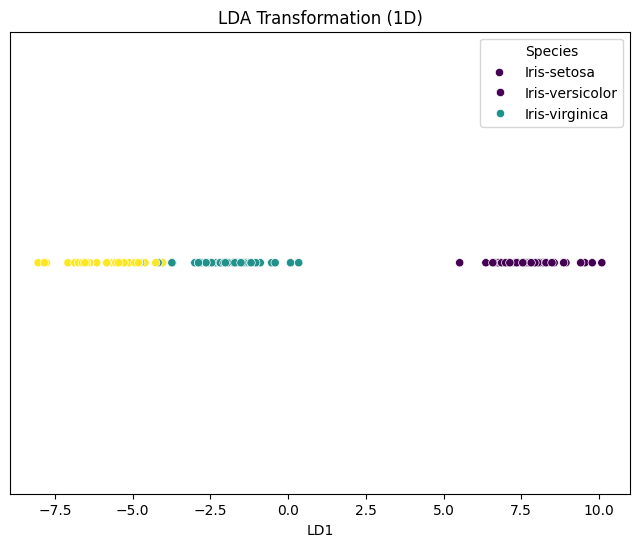

In [14]:
# Apply LDA with 1 component
lda_1d = LinearDiscriminantAnalysis(n_components=1)
X_train_lda_1d = lda_1d.fit_transform(X_train, y_train)

# Visualize the LDA transformation in 1D
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_lda_1d[:, 0], y=[0] * len(X_train_lda_1d), hue=y_train, palette='viridis')
plt.title('LDA Transformation (1D)')
plt.xlabel('LD1')
plt.yticks([])
plt.legend(title='Species', labels=target_names)
plt.show()

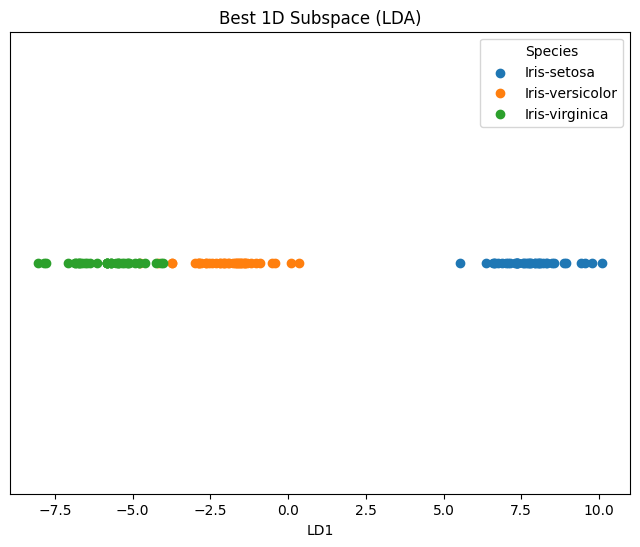

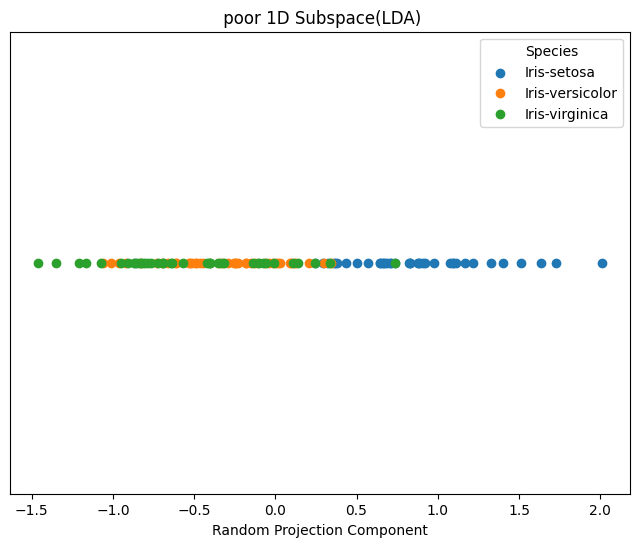

Eigenvalues: [0.99257284]


In [20]:
import numpy as np
from sklearn.random_projection import GaussianRandomProjection


lda_1d = LinearDiscriminantAnalysis(n_components=1)
X_train_lda_1d = lda_1d.fit_transform(X_train, y_train)

# Visualize the best subspace (LDA 1D projection)
plt.figure(figsize=(8, 6))
for i, species in enumerate(le.classes_):
    plt.scatter(X_train_lda_1d[y_train == i, 0], np.zeros_like(X_train_lda_1d[y_train == i, 0]), label=le.inverse_transform([i])[0])  # Plotting on X axis with Y as zero.
plt.title('Best 1D Subspace (LDA)')
plt.xlabel('LD1')
plt.yticks([])
plt.legend(title='Species')
plt.show()

# --- Worst Subspace (Random Projection) ---
# For the "worst" subspace, we'll use a random projection.  This will likely result in poor class separation.
# A truly *worst* subspace is difficult to define and calculate precisely, so we'll use this as an example.
# The calculation here is a random linear transformation: project each data point onto a randomly generated vector.

random_projection = GaussianRandomProjection(n_components=1)
X_train_random_1d = random_projection.fit_transform(X_train)  # Projection happens here

# Visualize the random 1D projection
plt.figure(figsize=(8, 6))
for i, species in enumerate(le.classes_):
    plt.scatter(X_train_random_1d[y_train == i, 0], np.zeros_like(X_train_random_1d[y_train == i, 0]), label=le.inverse_transform([i])[0]) #Plotting on X axis with Y as zero.
plt.title(' poor 1D Subspace(LDA)')
plt.xlabel('Random Projection Component')
plt.yticks([])
plt.legend(title='Species')
plt.show()


#Show the eigen values
lda = LinearDiscriminantAnalysis(n_components=1)
lda.fit(X_train, y_train)
print("Eigenvalues:", lda.explained_variance_ratio_)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.78      0.88         9
 Iris-virginica       0.85      1.00      0.92        11

       accuracy                           0.93        30
      macro avg       0.95      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



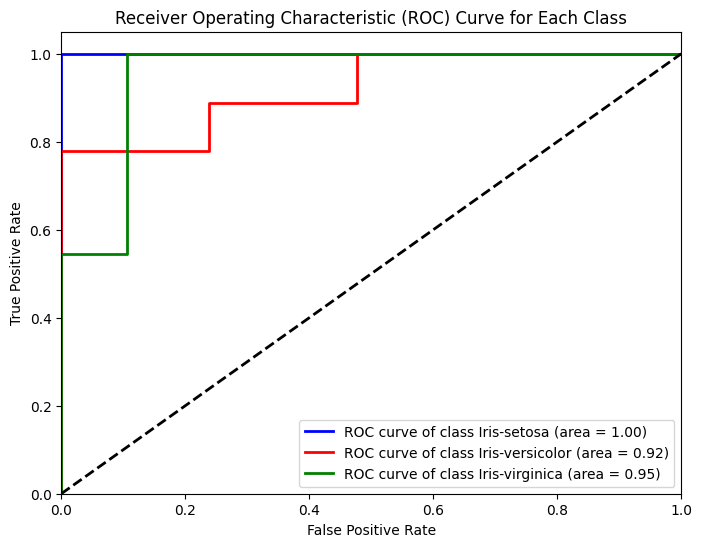

In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# --- Load data and preprocess ---
df = pd.read_csv("Iris.csv")
X = df.drop(columns=['Species', 'Id'])
y = df['Species']
le = LabelEncoder()
y = le.fit_transform(y)
X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  #Save the origial data
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test_full = scaler.transform(X_test_full)

# --- Feature Selection (First Two Features) ---
feature_indices = [0, 1]  # Indices of the two features to select (Sepal Length, Sepal Width)
X_train = X_train_full[:, feature_indices]
X_test = X_test_full[:, feature_indices]



# --- Model Training ---
model = LogisticRegression(multi_class='ovr', solver='liblinear', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# --- Classification Report (Precision, Recall, F1-score) ---
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# --- ROC Curve and AUC ---
n_classes = len(le.classes_)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Plot ROC curves for each class ---
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(le.classes_[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Each Class')
plt.legend(loc="lower right")
plt.show()

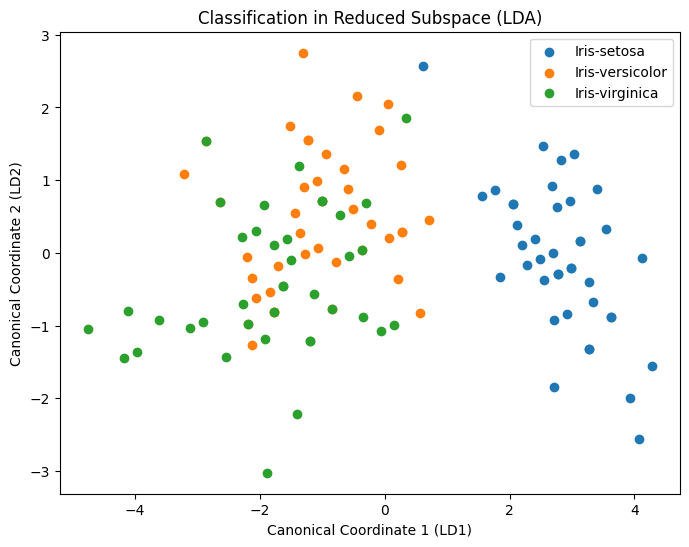

In [31]:
# --- Feature Selection (First Two Features) ---
X_train = X_train[:, [0, 1]]  # Sepal Length and Sepal Width
X_test = X_test[:, [0, 1]]


# --- Scatter Plot of Classification in Reduced Subspace ---
plt.figure(figsize=(8, 6))
for i, species in enumerate(le.classes_):
    plt.scatter(X_train_lda[y_train == i, 0], X_train_lda[y_train == i, 1], label=species)
plt.xlabel("Canonical Coordinate 1 (LD1)")
plt.ylabel("Canonical Coordinate 2 (LD2)")
plt.title("Classification in Reduced Subspace (LDA)")
plt.legend()
plt.show()

<ipython-input-34-bfd0a4cff167>:24: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_train_lda[y_train == i, 0], X_train_lda[y_train == i, 1], label=species, cmap=cmap_bold)  #Plot the scattering data points


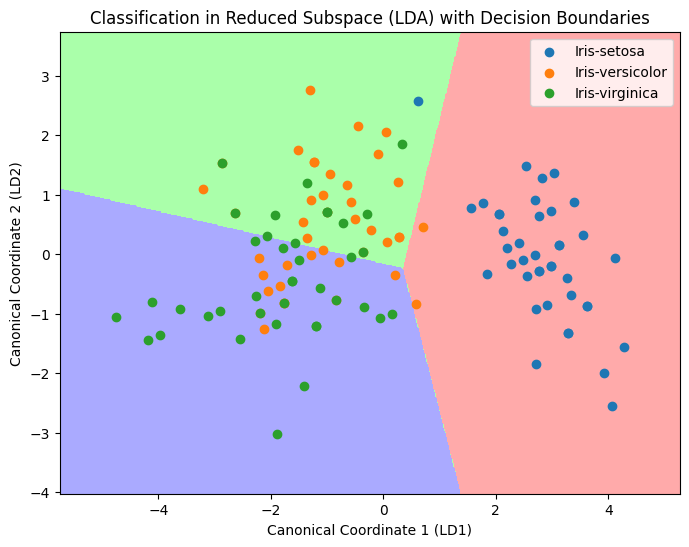

In [34]:

from matplotlib.colors import ListedColormap


# --- Scatter Plot of Classification in Reduced Subspace with Decision Boundaries ---
plt.figure(figsize=(8, 6))

# Create a meshgrid to plot in
h = .02  # step size in the mesh
x_min, x_max = X_train_lda[:, 0].min() - 1, X_train_lda[:, 0].max() + 1
y_min, y_max = X_train_lda[:, 1].min() - 1, X_train_lda[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Obtain predictions for each point in mesh grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)



plt.contourf(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
for i, species in enumerate(le.classes_):
    plt.scatter(X_train_lda[y_train == i, 0], X_train_lda[y_train == i, 1], label=species, cmap=cmap_bold)  #Plot the scattering data points

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Canonical Coordinate 1 (LD1)")
plt.ylabel("Canonical Coordinate 2 (LD2)")
plt.title("Classification in Reduced Subspace (LDA) with Decision Boundaries")
plt.legend()
plt.show()